In [1]:
import numpy as np
import scipy.stats
import pylab as plt
from tqdm.notebook import tqdm

(array([0.31057269, 0.31814763, 0.32572257, 0.26133555, 0.25754808,
        0.31436016, 0.28027291, 0.2954228 , 0.21588589, 0.22724831,
        0.15528634, 0.19316106, 0.1211991 , 0.09847427, 0.06059955,
        0.04923713, 0.07196196, 0.03787472, 0.04166219, 0.02272483,
        0.01514989, 0.03787472, 0.0265123 , 0.01136242, 0.01136242,
        0.00757494, 0.00757494, 0.        , 0.00757494, 0.00378747]),
 array([3.41901084e-03, 2.67447381e-01, 5.31475751e-01, 7.95504122e-01,
        1.05953249e+00, 1.32356086e+00, 1.58758923e+00, 1.85161760e+00,
        2.11564597e+00, 2.37967434e+00, 2.64370271e+00, 2.90773108e+00,
        3.17175945e+00, 3.43578782e+00, 3.69981619e+00, 3.96384456e+00,
        4.22787293e+00, 4.49190131e+00, 4.75592968e+00, 5.01995805e+00,
        5.28398642e+00, 5.54801479e+00, 5.81204316e+00, 6.07607153e+00,
        6.34009990e+00, 6.60412827e+00, 6.86815664e+00, 7.13218501e+00,
        7.39621338e+00, 7.66024175e+00, 7.92427012e+00]),
 <BarContainer object of 30 

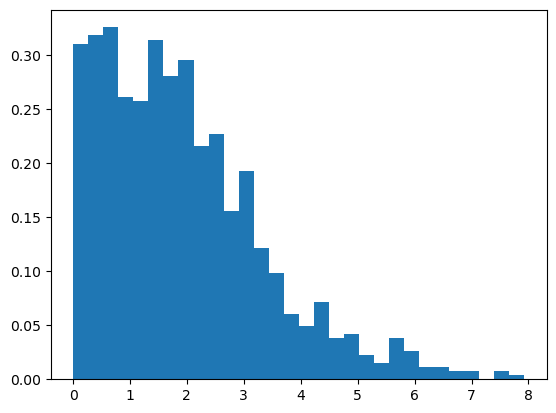

In [2]:
mu = 0
sigma=2.4
N=1000

distGauss = scipy.stats.norm(loc=0, scale=sigma)
plt.hist(np.abs(distGauss.rvs(N)), density=True, bins=30)

In [3]:
x = np.abs(distGauss.rvs(N))
integral = sigma*(np.pi/2)**0.5 * np.mean(x**3)
result= 2*sigma**4 

print(integral, result, np.abs(integral-result)/result)

65.18198326833542 66.3552 0.017680855933891865


In [4]:
def integral(s, N):
    distGauss = scipy.stats.norm(loc=0, scale=s)
    x = np.abs(distGauss.rvs(N))
    normal = s*(np.pi/2)**0.5
    return normal*np.mean(x**3) #, norm * scipy.stats.tstd(x**3) / N**0.5

def knownresult(s):
    return 2*s**4

sigma = 0.45
Nvals = np.unique(np.logspace(0, 6, 100, dtype=int))
print(Nvals)

[      1       2       3       4       5       6       7       8       9
      10      12      14      16      18      21      24      28      32
      37      43      49      57      65      75      86     100     114
     132     151     174     200     231     265     305     351     403
     464     533     613     705     811     932    1072    1232    1417
    1629    1873    2154    2477    2848    3274    3764    4328    4977
    5722    6579    7564    8697   10000   11497   13219   15199   17475
   20092   23101   26560   30538   35111   40370   46415   53366   61359
   70548   81113   93260  107226  123284  141747  162975  187381  215443
  247707  284803  327454  376493  432876  497702  572236  657933  756463
  869749 1000000]


  0%|          | 0/92 [00:00<?, ?it/s]

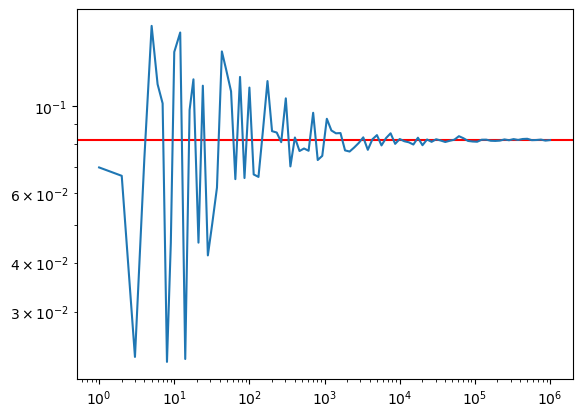

In [5]:
results = np.array([integral(sigma, N) for N in tqdm(Nvals)])
plt.axhline(knownresult(sigma),c='red')
plt.plot(Nvals,results)
plt.loglog()
plt.show()

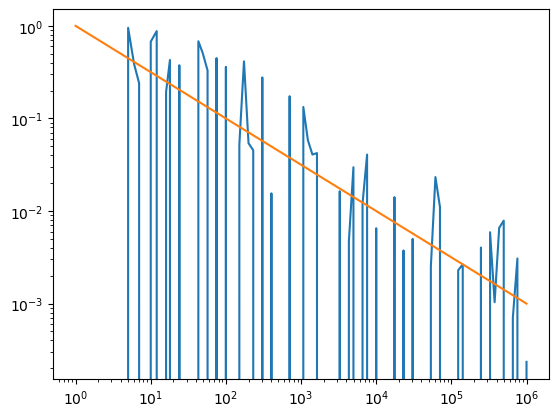

In [6]:
plt.axhline(0,c='red')
plt.plot(Nvals, (results - knownresult(sigma))/knownresult(sigma))
plt.plot(Nvals, Nvals**-0.5)

plt.loglog()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

(array([ 0.23859169,  0.23859169,  0.        ,  0.23859169,  0.        ,
         0.        ,  0.47718337,  0.47718337,  0.95436674,  0.95436674,
         1.43155012,  1.43155012,  3.10169192,  2.14732517,  3.81746698,
         3.81746698,  4.05605866,  7.39634226,  8.35070901, 10.2594425 ,
        10.49803418, 15.74705127, 17.17860139, 17.17860139, 18.37155982,
        20.51888499, 23.14339354, 24.57494365, 28.63100232, 34.35720278,
        35.07297784, 43.42368685, 47.71833719, 45.57101202, 44.85523696,
        50.34284574, 55.11467946, 56.30763789, 61.31806329, 68.23722219,
        57.97777969, 66.80567207, 68.71440556, 72.29328085, 63.46538847,
        78.97384805, 70.62313905, 67.9986305 , 65.85130533, 70.38454736,
        64.18116352, 62.9882051 , 63.46538847, 55.83045452, 62.51102172,
        47.95692888, 50.34284574, 43.18509516, 45.80960371, 41.27636167,
        38.89044481, 38.41326144, 31.25551086, 32.20987761, 29.10818569,
        26.48367714, 24.09776028, 22.18902679, 19.8

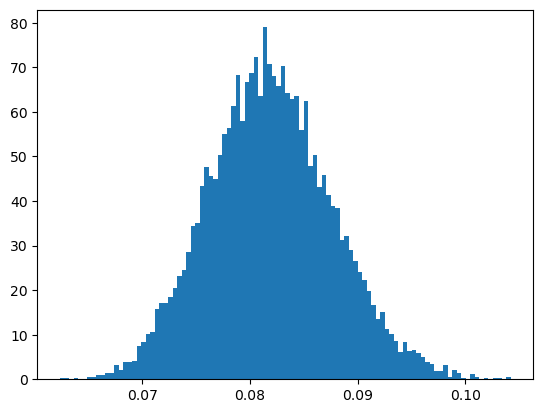

In [7]:
N = 1000
realizations = 10000
results = np.array([integral(sigma, N) for i in tqdm(range(realizations))])

plt.hist(results, density=True, bins=100)

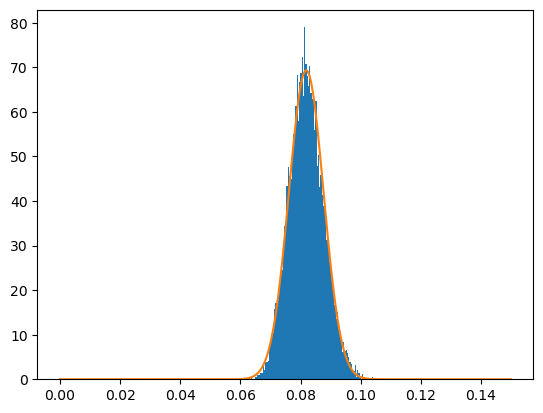

In [8]:
mean = np.average(results)
std = np.std(results, ddof=1)

plt.hist(results, density=True, bins=100)
distGauss = scipy.stats.norm(loc=mean, scale=std)

x = np.linspace(0, 0.15, 1000)

plt.plot(x, distGauss.pdf(x));